# Módulo 6 — La dualidad AR(1) = MA(∞)
Simulación real: generamos una serie AR(1) y comprobamos numéricamente que se puede aproximar con un modelo MA(q) de orden creciente, con coeficientes theta_k = phi^k.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)

## Simulamos una serie AR(1) real: x_t = 0.6 x_{t-1} + eps_t

In [2]:
n = 3000
phi = 0.6
c = 0.0
eps = np.random.normal(0, 1, n)
x = np.zeros(n)
for t in range(1, n):
    x[t] = c + phi * x[t-1] + eps[t]
x = x[500:]  # descartamos las primeras 500 observaciones (burn-in)
print("primeros 5 valores de la serie AR(1) simulada:", np.round(x[:5], 4))
print("media:", round(x.mean(), 4), " varianza:", round(x.var(), 4))

primeros 5 valores de la serie AR(1) simulada: [-0.2853  1.7382 -0.3556  0.3496 -0.4409]
media: 0.0916  varianza: 1.501


## Aproximación teórica: truncar el MA(∞) en distintos q y medir el error

In [3]:
for q in [1, 5, 20, 50]:
    theta = np.array([phi**k for k in range(1, q+1)])
    approx = np.zeros(len(x))
    for t in range(q, len(x)):
        approx[t] = eps[500+t] + np.sum(theta * eps[500+t-1:500+t-1-q:-1])
    mask = slice(q, len(x))
    err = x[mask] - approx[mask]
    print(f"q={q:>3}  |  error cuadratico medio MA({q}) truncado vs AR(1) real: {np.mean(err**2):.6f}")

q=  1  |  error cuadratico medio MA(1) truncado vs AR(1) real: 0.195886
q=  5  |  error cuadratico medio MA(5) truncado vs AR(1) real: 0.003294
q= 20  |  error cuadratico medio MA(20) truncado vs AR(1) real: 0.000000
q= 50  |  error cuadratico medio MA(50) truncado vs AR(1) real: 0.000000


## Ajustamos un MA(20) real sobre la serie AR(1) simulada y comparamos coeficientes

In [4]:
model = ARIMA(x, order=(0, 0, 20))
res = model.fit()
theta_hat = res.params[1:21]
print("primeros 6 coeficientes MA estimados (theta_k):")
print(np.round(theta_hat[:6], 4))
print("primeros 6 valores teoricos phi^k:", np.round([phi**k for k in range(1, 7)], 4))
print("AIC MA(20) sobre serie generada por AR(1):", res.aic)

model_ar1 = ARIMA(x, order=(1, 0, 0))
res_ar1 = model_ar1.fit()
print("\nAjuste directo AR(1) sobre la misma serie:")
print("phi estimado:", round(res_ar1.params[1], 4), " (verdadero:", phi, ")")
print("AIC AR(1):", res_ar1.aic)

primeros 6 coeficientes MA estimados (theta_k):
[0.5912 0.3449 0.2227 0.1151 0.0881 0.0466]
primeros 6 valores teoricos phi^k: [0.6    0.36   0.216  0.1296 0.0778 0.0467]
AIC MA(20) sobre serie generada por AR(1): 7062.995206333786

Ajuste directo AR(1) sobre la misma serie:
phi estimado: 0.5915  (verdadero: 0.6 )
AIC AR(1): 7038.94859892804


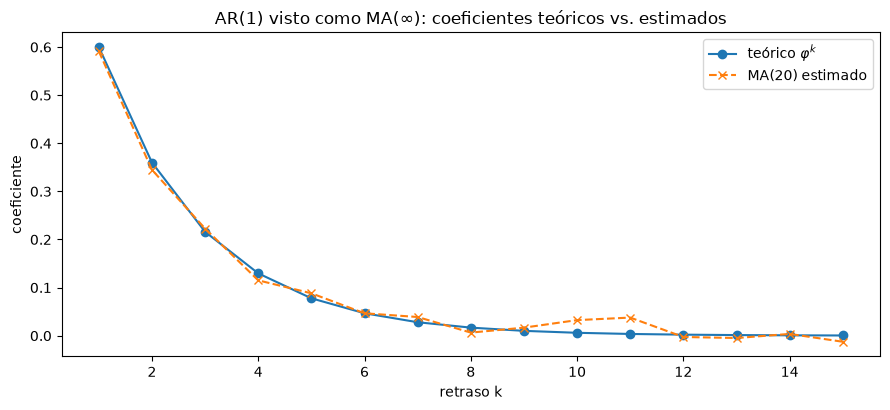

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ks = np.arange(1, 16)
ax.plot(ks, phi**ks, "o-", label="teórico $\\varphi^k$")
ax.plot(ks, theta_hat[:15], "x--", label="MA(20) estimado")
ax.set_xlabel("retraso k")
ax.set_ylabel("coeficiente")
ax.legend()
plt.title("AR(1) visto como MA(∞): coeficientes teóricos vs. estimados")
plt.tight_layout()
plt.show()